## Assignment 4

Author: John Courtright\
Course: ISAN 5357\
Instructor: Dr. Zareef Mohammed

In [38]:
import pandas as pd
pk = pd.read_csv('pokemon.csv')
# print(pk.info())

The 'pokemon.csv' file contains information about the 801 Pokemon from Gen 1 through Gen 7. Each row represents a Pokemon and the records are in order by Pokedex number. There are 41 columns which contain various stats about the Pokemon, such as their type, combat statistics, and the damage multipliers moves of a given type have against that Pokemon in combat. 

For this notebook, we're going to examine Pokemon types. We'd like to examine how common each type is, how each type distributes its stats across the 6 base Pokemon stats, and how each type compares to each other with their average stat values.

First, let's visualize the types based on how commonly they appear in our data set.

In [ ]:
# Get value counts of type1 and type2
type1_counts = pk['type1'].value_counts()
type2_counts = pk['type2'].value_counts()

# Sum the counts
total_type_counts = type1_counts.add(type2_counts, fill_value=0)
# print(total_type_counts)

bug          77
dark         50
dragon       44
electric     48
fairy        47
fighting     53
fire         65
flying       98
ghost        41
grass        98
ground       66
ice          38
normal      109
poison       66
psychic      82
rock         59
steel        46
water       131
Name: count, dtype: int64


In [7]:
# From: https://gist.github.com/apaleslimghost/0d25ec801ca4fc43317bcff298af43c3
type_colors = {
    'normal': '#A8A77A',
    'fire': '#EE8130',
    'water': '#6390F0',
    'electric': '#F7D02C',
    'grass': '#7AC74C',
    'ice': '#96D9D6',
    'fighting': '#C22E28',
    'poison': '#A33EA1',
    'ground': '#E2BF65',
    'flying': '#A98FF3',
    'psychic': '#F95587',
    'bug': '#A6B91A',
    'rock': '#B6A136',
    'ghost': '#735797',
    'dragon': '#6F35FC',
    'dark': '#705746',
    'steel': '#B7B7CE',
    'fairy': '#D685AD'
}

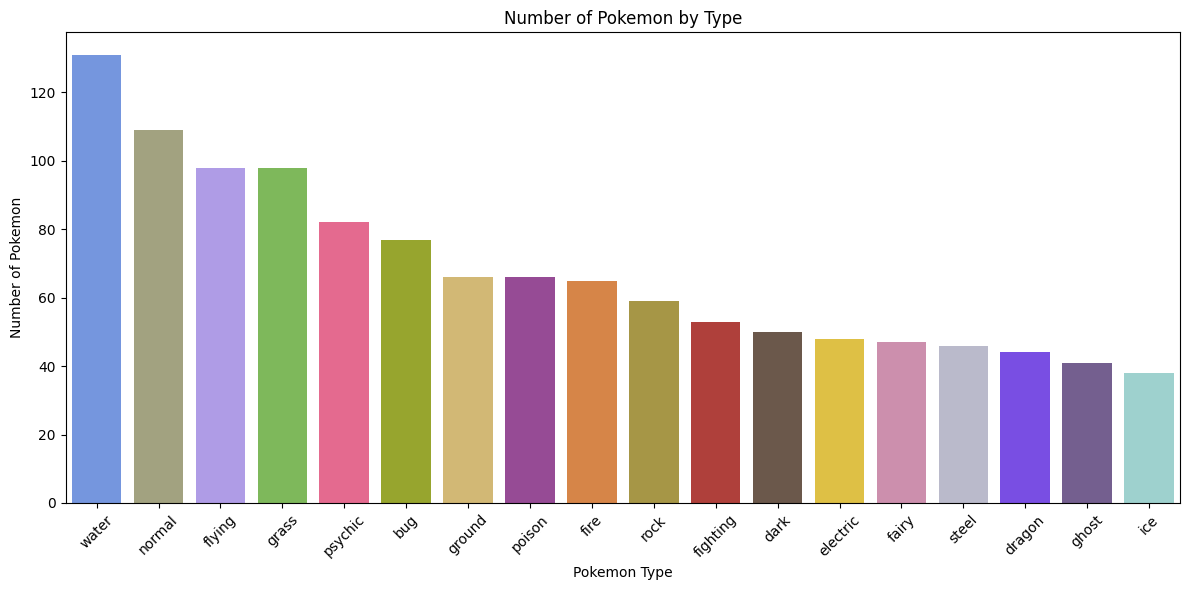

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort in descending order
total_type_counts = total_type_counts.sort_values(ascending=False)

# Build palette based on type colors
palette = [type_colors[t.lower()] for t in total_type_counts.index]

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(
    x = total_type_counts.index,
    y = total_type_counts.values,
    palette = palette,
    hue = total_type_counts.index
)

plt.title('Number of Pokemon by Type')
plt.xlabel('Pokemon Type')
plt.ylabel('Number of Pokemon')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Water is the most common type, with 131 Pokemon having it as their primary or secondary type. Normal and flying are the next most common. Dragon, ghost, and ice are the least common. 

We can also examine how common the types are as primary and secondary types.

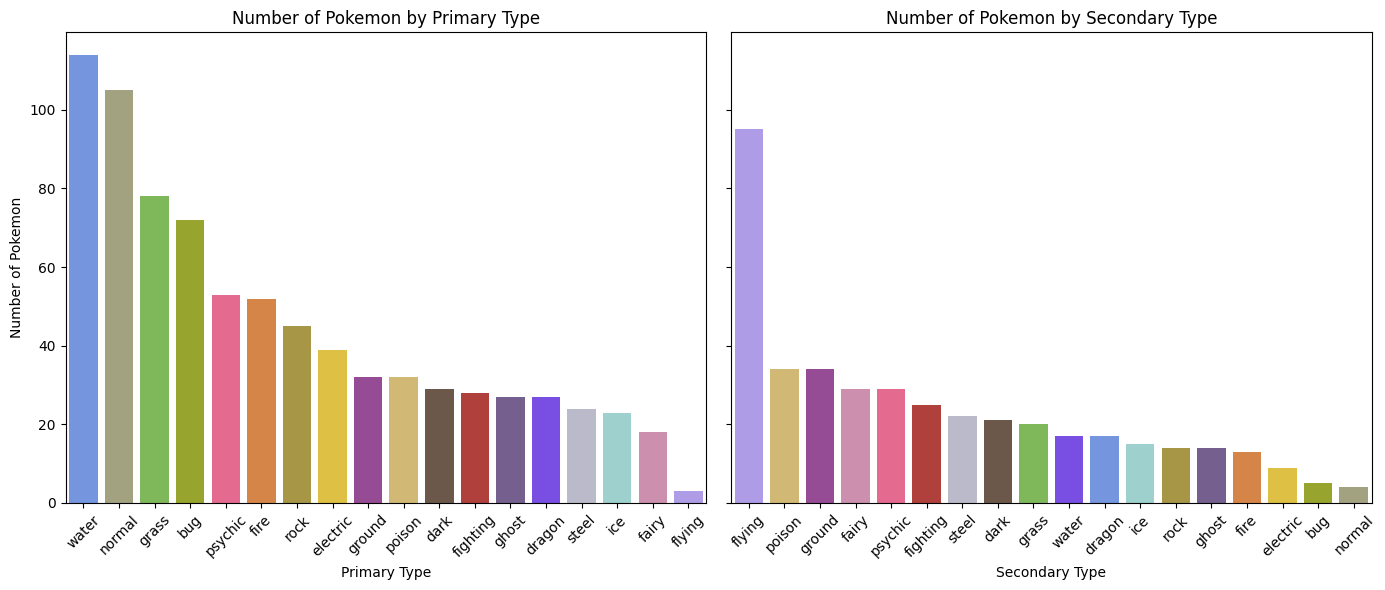

In [12]:
# Create figure plane (2 subplots side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
# sharey=True makes y-axis the same for both plots

# We need two seperate palettes for type1 and type2
palette1 = [type_colors[t.lower()] for t in type1_counts.index]
palette2 = [type_colors[t.lower()] for t in type2_counts.index]

# Primary type plot
type1_counts = type1_counts.sort_values(ascending=False)
sns.barplot(
    x = type1_counts.index,
    y = type1_counts.values,
    palette = palette1,
    hue = type1_counts.index,
    ax = axes[0]
)
axes[0].set_title('Number of Pokemon by Primary Type')
axes[0].set_xlabel('Primary Type')
axes[0].set_ylabel('Number of Pokemon')
axes[0].tick_params(axis='x', rotation=45)

# Secondary type plot
type2_counts = type2_counts.sort_values(ascending=False)
sns.barplot(
    x = type2_counts.index,
    y = type2_counts.values,
    palette = palette2,
    hue = type2_counts.index,
    ax = axes[1]
)
axes[1].set_title('Number of Pokemon by Secondary Type')
axes[1].set_xlabel('Secondary Type')
axes[1].set_ylabel('')  # No need for y-label on the right plot
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The top 3 most common primary types are Water, Normal, and Grass. Flying, which was the third most common type, gets knocked down to last. By Gen 7, there were only 3 Pokemon that were only Flying type or had Flying as their primary type: Tornadus, Noibat, and Noivern.

Flying, Poison, and Ground are the most common secondary types. There are a plethora of Normal-Flying types and Grass/Bug-Poison types. Ground being high is curious. When examining the list of Ground type Pokemon, Ground serves as the secondary type for a variety of other types, such as Rock, Water, Ice, and Dragon.

The fairy type was introduced in Gen 6, and many Pokemon had their types retroactively changed to feature the type. Not many Pokemon have Fairy as their primary type, but Fairy is the fourth most common secondary type. 

Different types have different strengths. One of the most common type archetypes is the 'bulky Water type', a Water type with great HP, Defense, and Special Defense. There are 6 main stats: HP, Attack, Special Attack, Defense, Special Defense, and Speed. We can create density plots for each of these stats and see how the different types distribute their stats. 

In [21]:
# Colors from https://bulbapedia.bulbagarden.net/wiki/Help:Color_templates#Pok%C3%A9mon_Stats
stat_colors = {
    'hp': '#69DC12',
    'attack': '#EFCC18',
    'defense': '#E86412',
    'sp_attack': '#14C3F1',
    'sp_defense': '#4A6ADF',
    'speed': '#D51DAD'
}

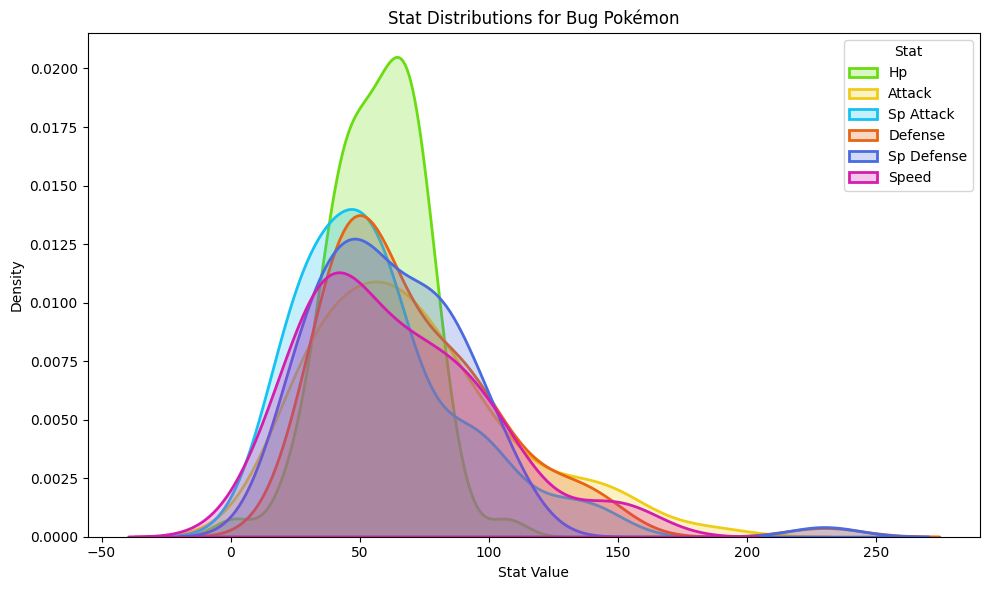

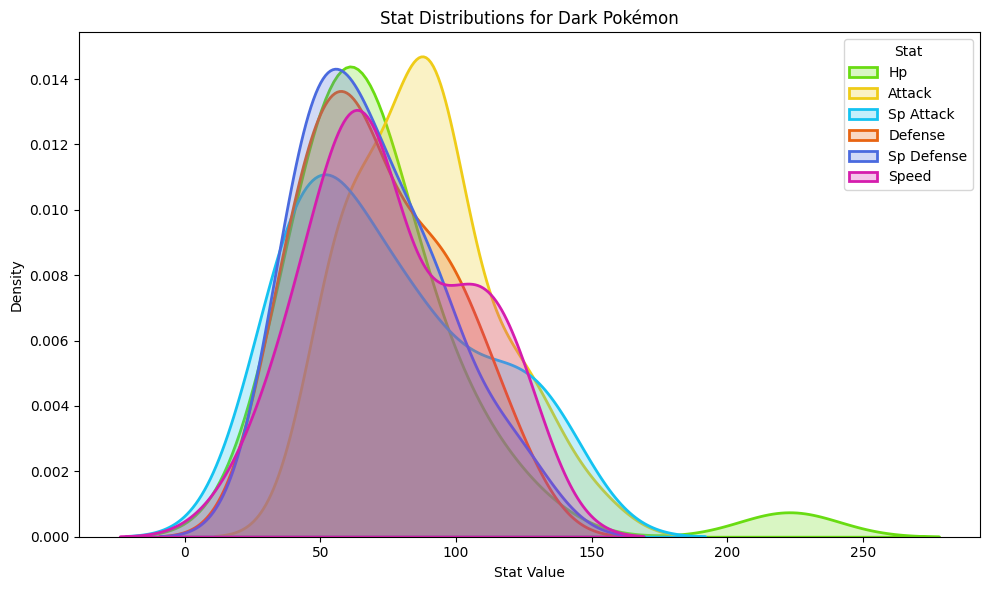

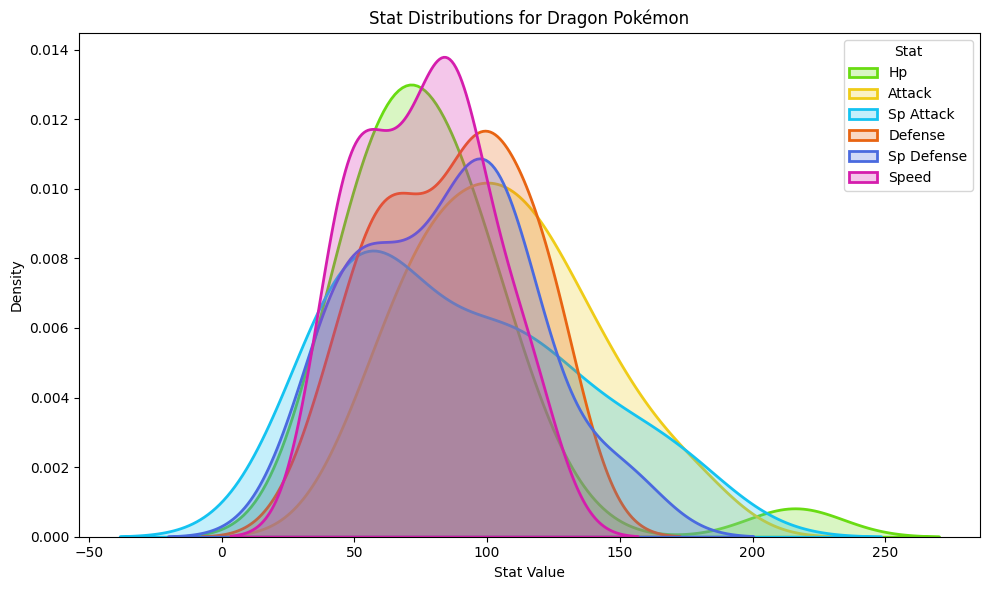

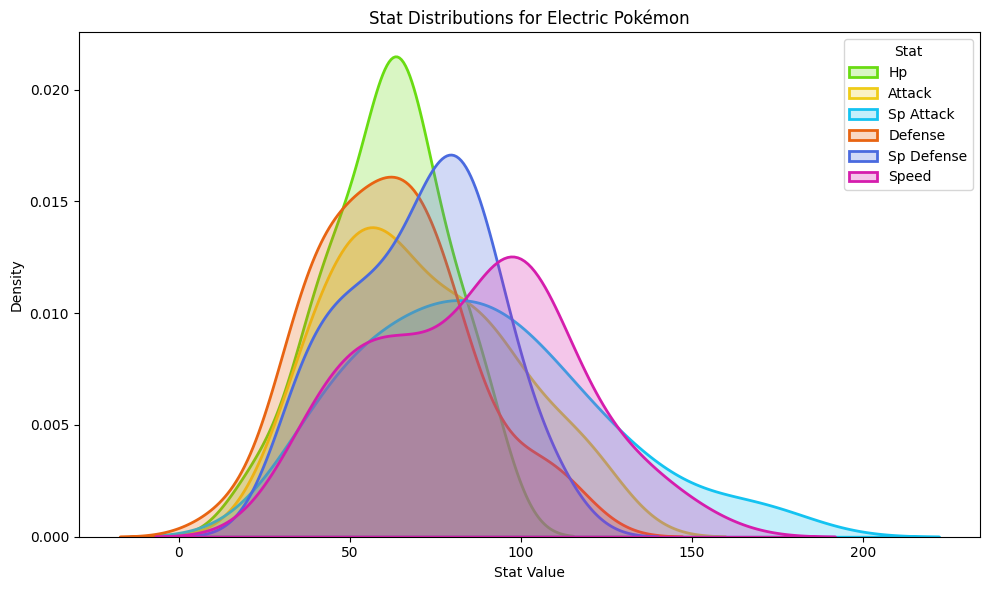

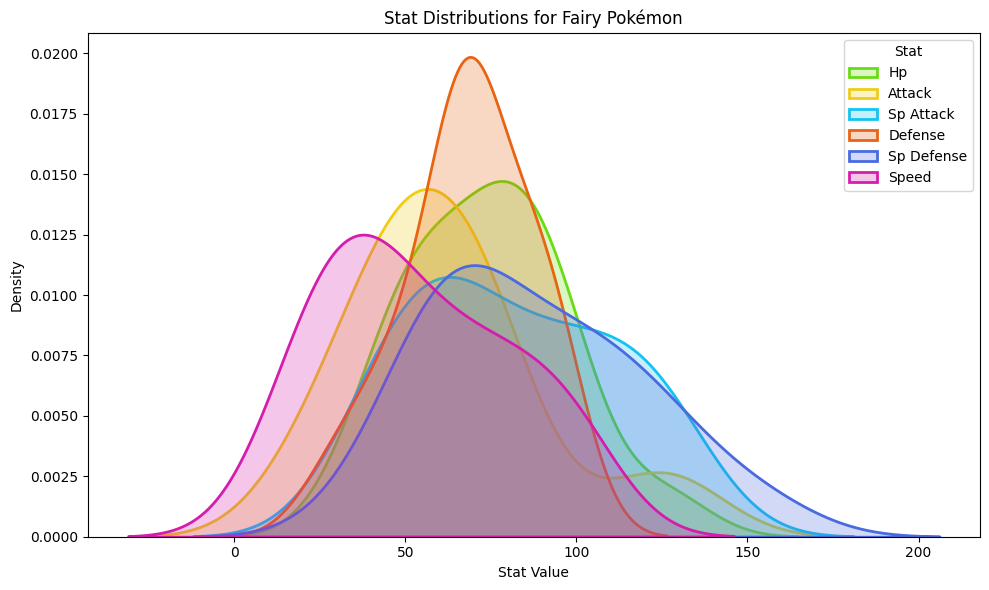

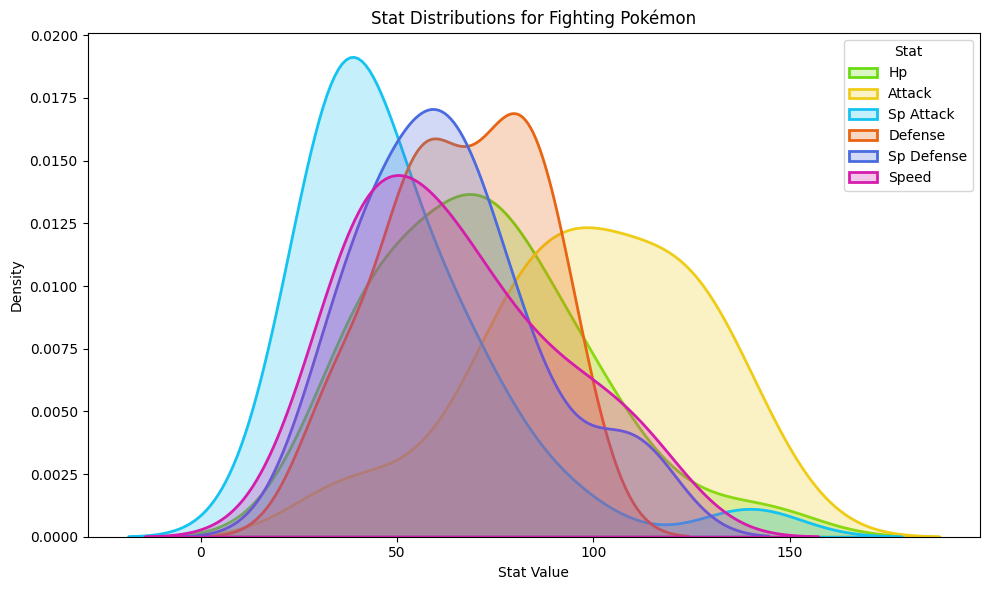

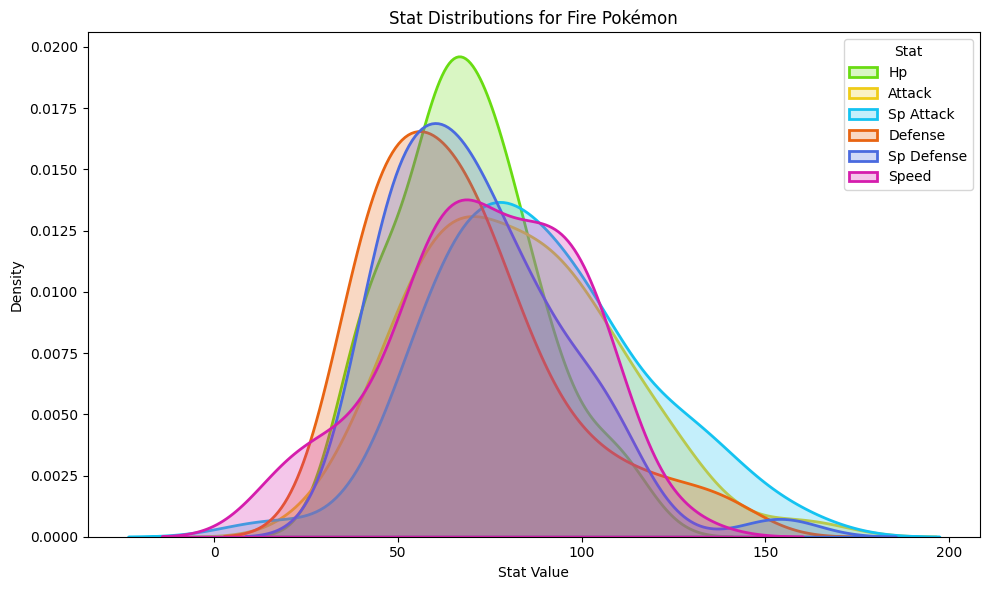

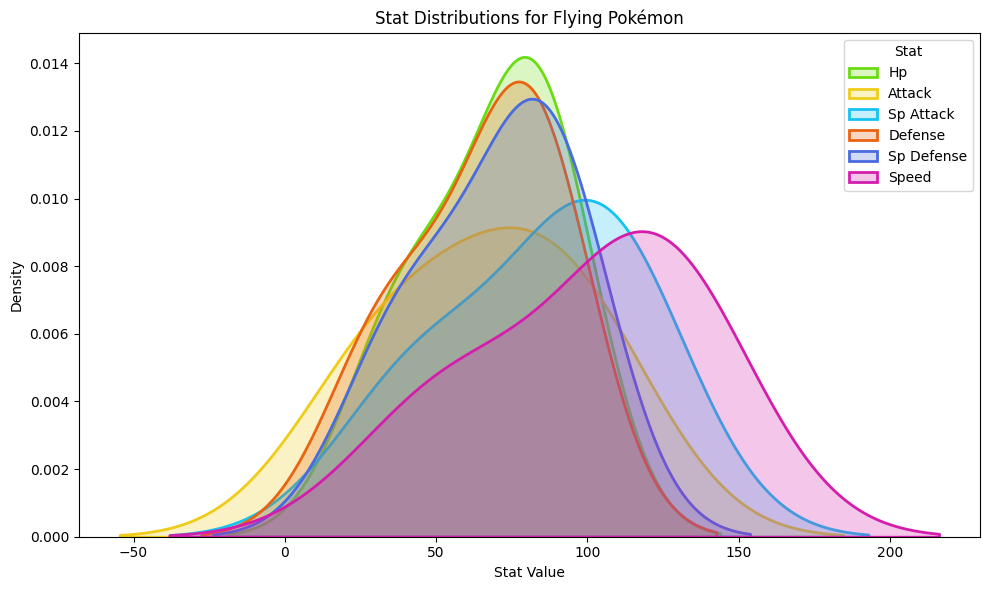

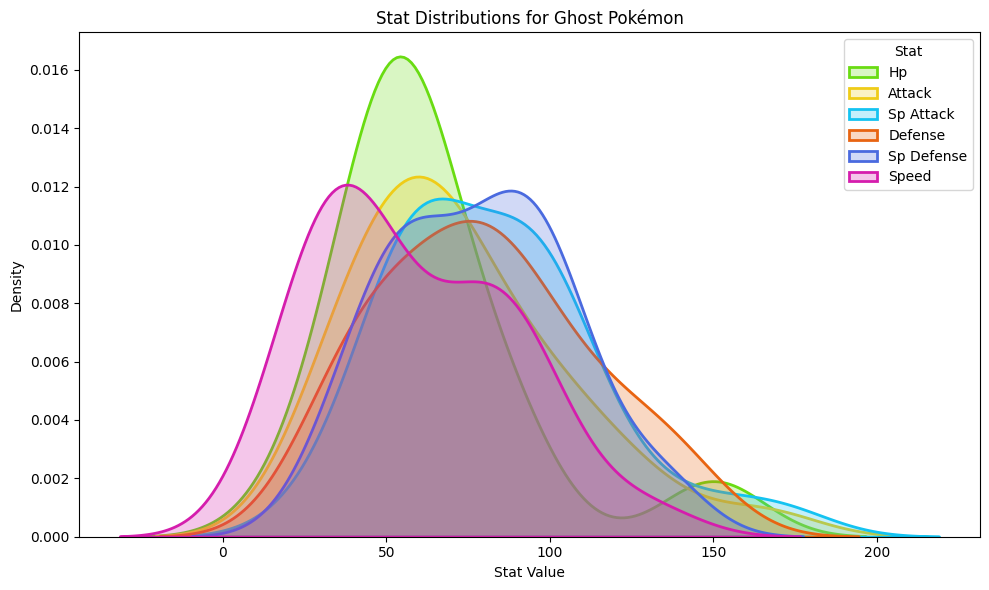

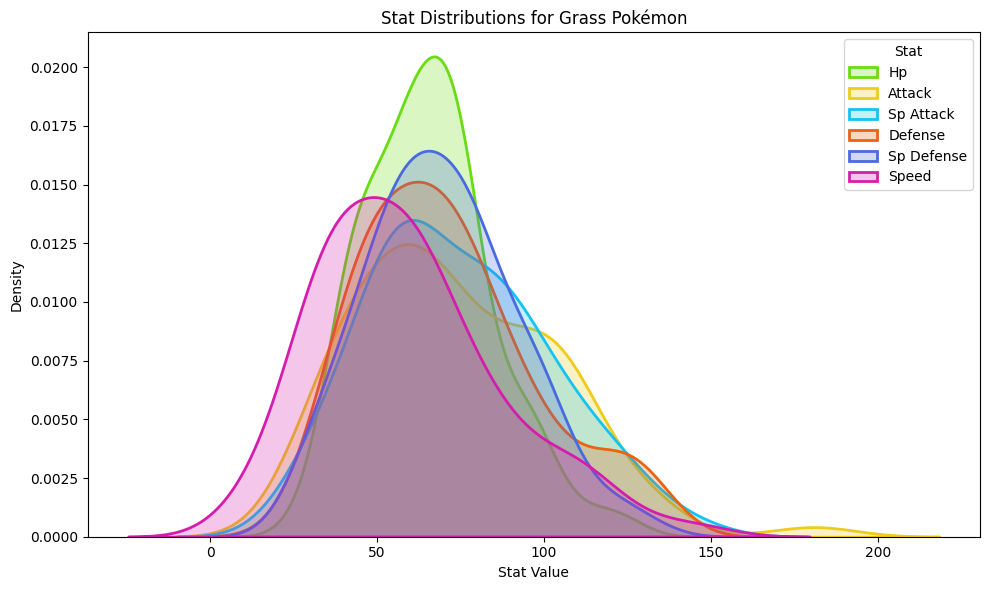

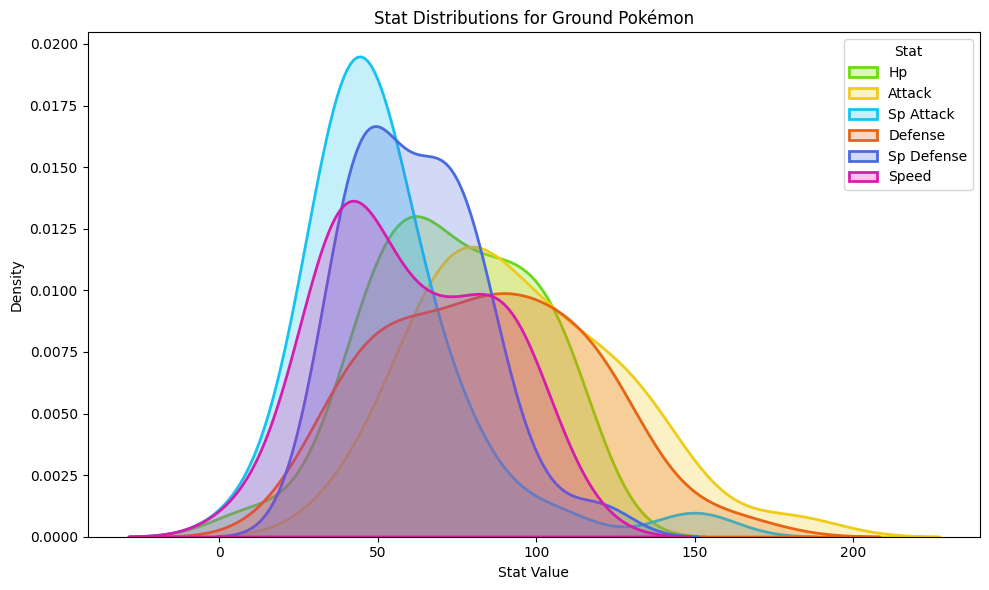

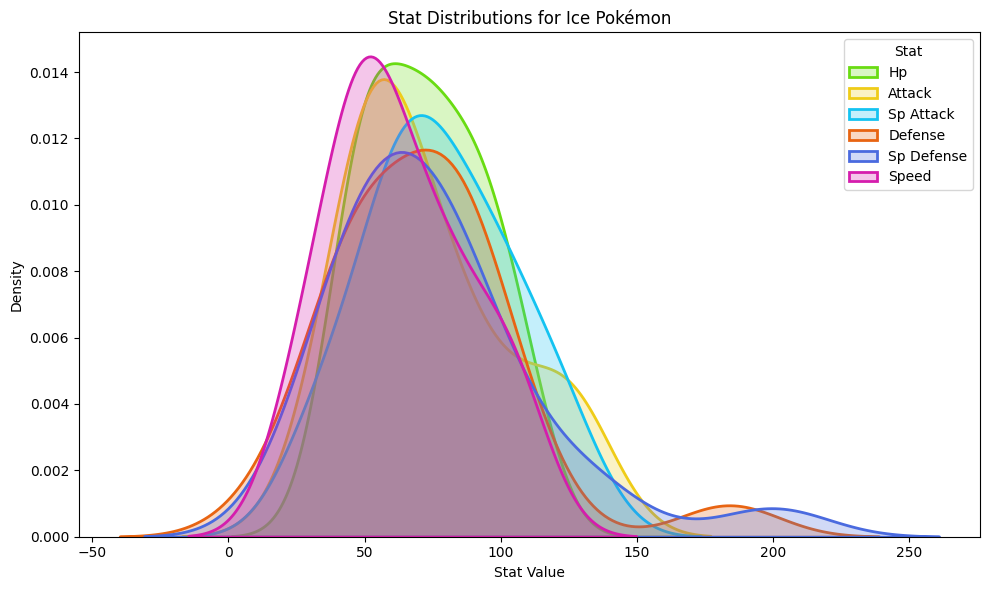

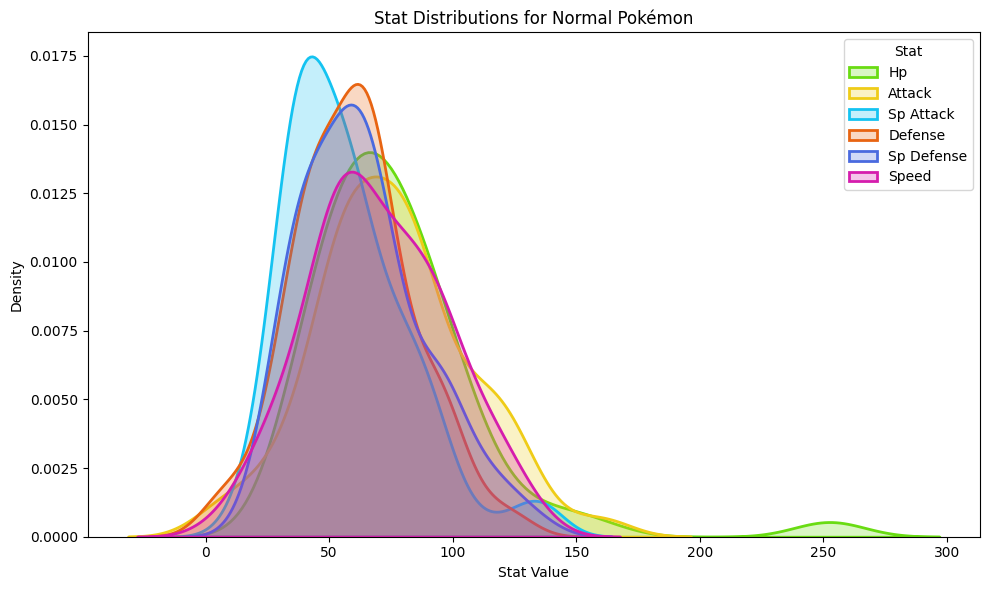

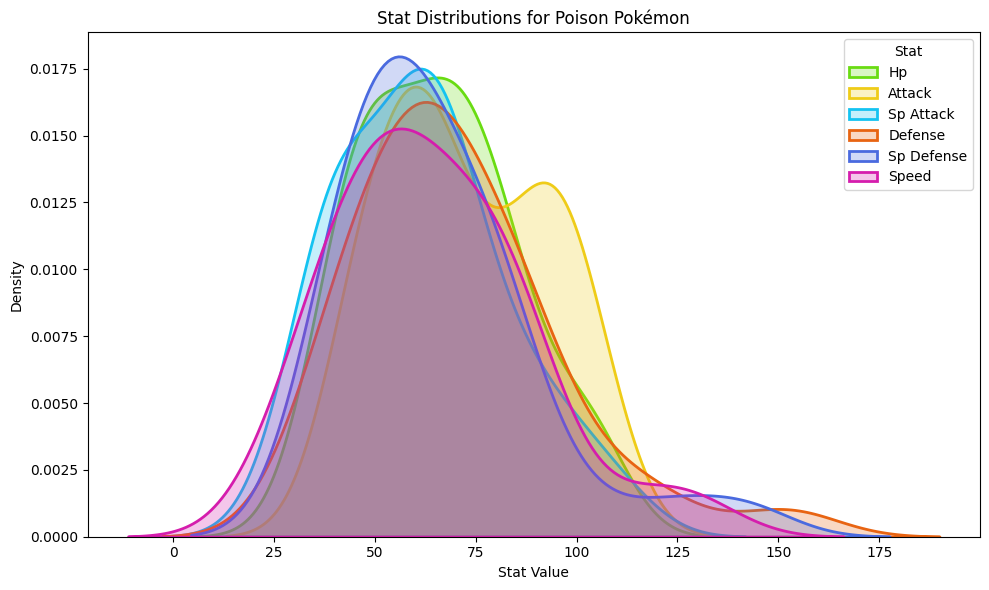

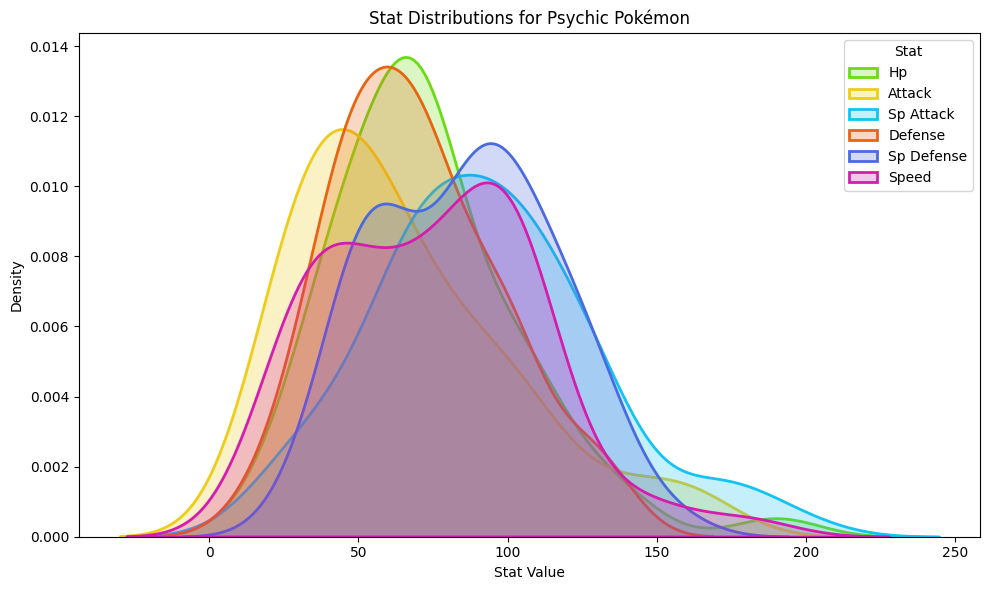

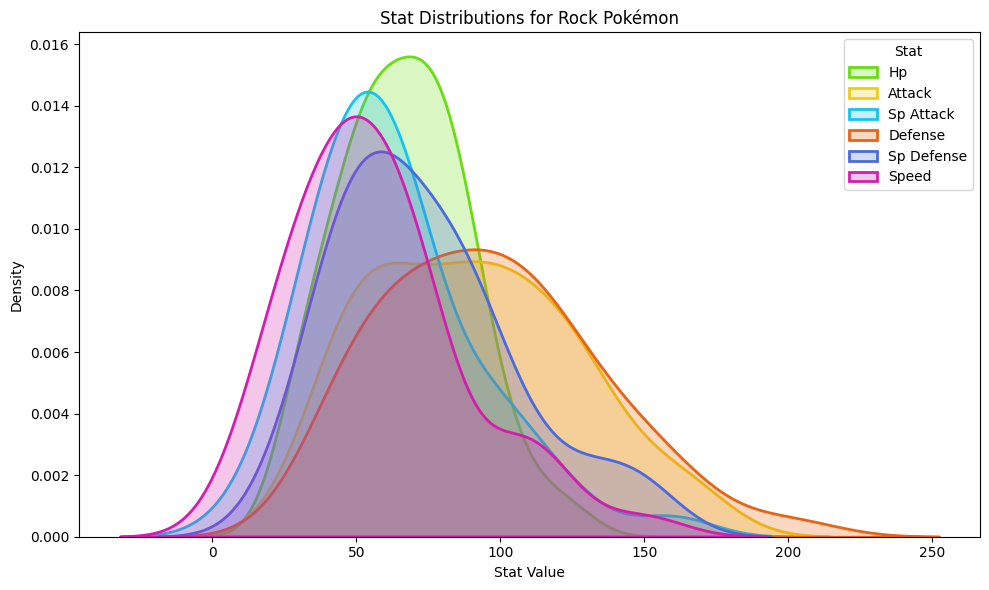

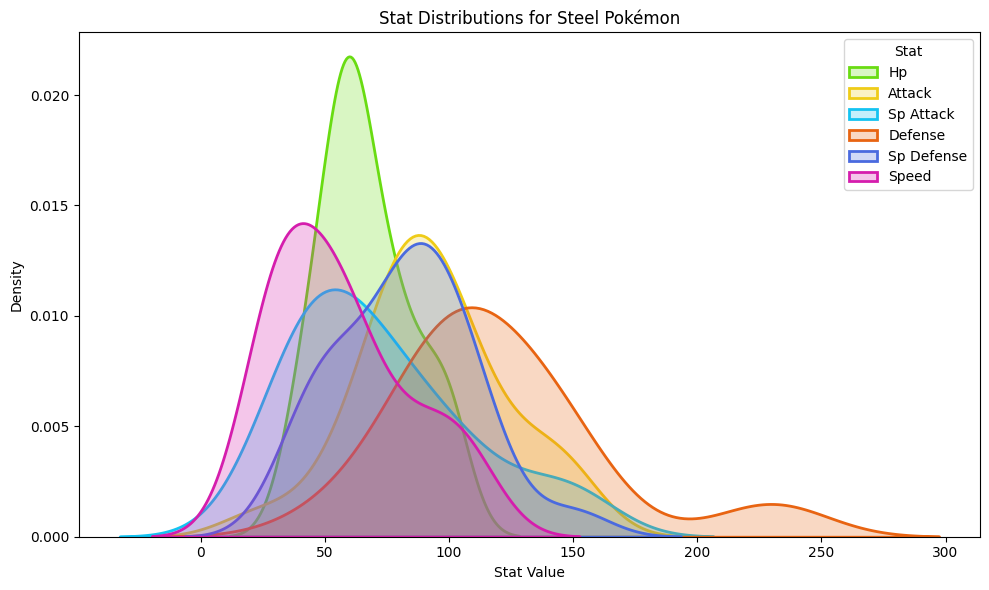

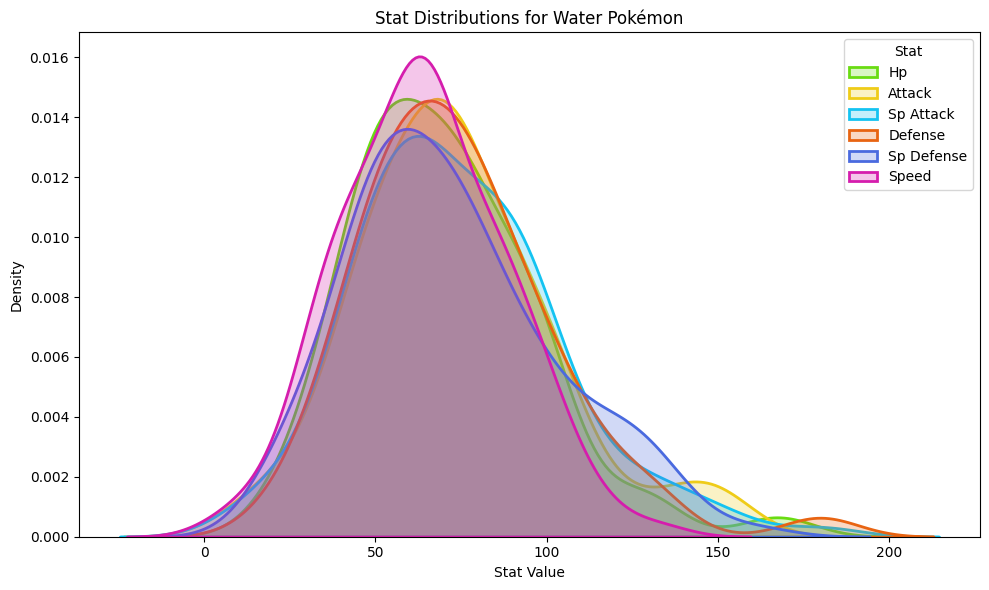

In [22]:
# For simplicity, we'll only consider primary types
types_sorted = sorted(pk['type1'].unique())

stats = ['hp', 'attack', 'sp_attack', 'defense', 'sp_defense', 'speed']

# Create a plot for each type
for t in types_sorted:
    plt.figure(figsize=(10, 6))

    # Subset the data for the current type
    subset = pk[pk['type1'] == t]

    # Plot the distributions for each stat
    for stat in stats:
        if subset[stat].nunique() > 1:   # KDE requires variation
            sns.kdeplot(
                data = subset,
                x = stat,
                linewidth = 2,
                fill = True,
                alpha = 0.25,
                color = stat_colors[stat],
                label = stat.replace("_", " ").title() # Format stat name nicely
            )

    plt.title(f"Stat Distributions for {t.capitalize()} Pokémon")
    plt.xlabel("Stat Value")
    plt.ylabel("Density")
    plt.legend(title="Stat")
    plt.tight_layout()
    plt.show()

18 density plots later, we can now examine how each primary type tends to distribute their stat points. In general, there's a large amount of overlap in stats. Each type has a variety of Pokemon, each with their own unique distributions, but the stat points don't vary so wildly that it would create extreme changes in the distribution of the stat. There are some notable examples of a type having a distinctly high distribution of a certain stat. Fighting types tend to have a lot of attack (duh). Flying types tend to be very fast (duh). Steel types are very durable on the physical side (duh). 

We can also see how some types are very balanced. Water, Poison, Dark, and Normal types have a lot of overlap in their fields. There are also instances of the line for a stat flattening out, but suddenly seeing a bump at a very high stat value. These bumps likely represent extremes, such as a certain Pokemon heavily investing in one stat or a Legendary Pokemon having high stats across the board.

To see which type has the highest average per stat, we can use the groupby method in pandas.

In [32]:
stats = ['hp', 'attack', 'sp_attack', 'defense', 'sp_defense', 'speed']

# Calculate the average stats per primary type
avg_stats = (
    pk.groupby('type1')[stats]
      .mean()
      .sort_index()
      .round(2)
)

# Get the highest and lowest average per stat
best_per_stat = avg_stats.idxmax()
worst_per_stat = avg_stats.idxmin()

# Create a summary DataFrame
comparison = pd.DataFrame({
    "Best Type": avg_stats.idxmax(),
    "Best Value": avg_stats.max(),
    "Worst Type": avg_stats.idxmin(),
    "Worst Value": avg_stats.min()
})

comparison

,Best Type,Best Value,Worst Type,Worst Value
hp,dragon,79.85,bug,56.72
attack,dragon,106.41,fairy,62.11
sp_attack,psychic,92.60,fighting,50.11
defense,steel,120.21,normal,59.70
sp_defense,fairy,87.78,ground,62.28
speed,flying,99.67,fairy,53.67


Dragon types have the highest average value in two stats: HP and Attack. The other 4 stats are occupied by unique types: Psychic for sp. attack, Steel for defense, Fairy for sp. defense, and Flying for speed. 

Fairy types occupy 2 stats for the worst average value: Attack and Speed. Bug has the lowest average HP, Fighting for sp. attack, Normal for defense, and Ground for sp. defense. 

We can construct a heatmap to better visualize how the types stack up in each stat. 

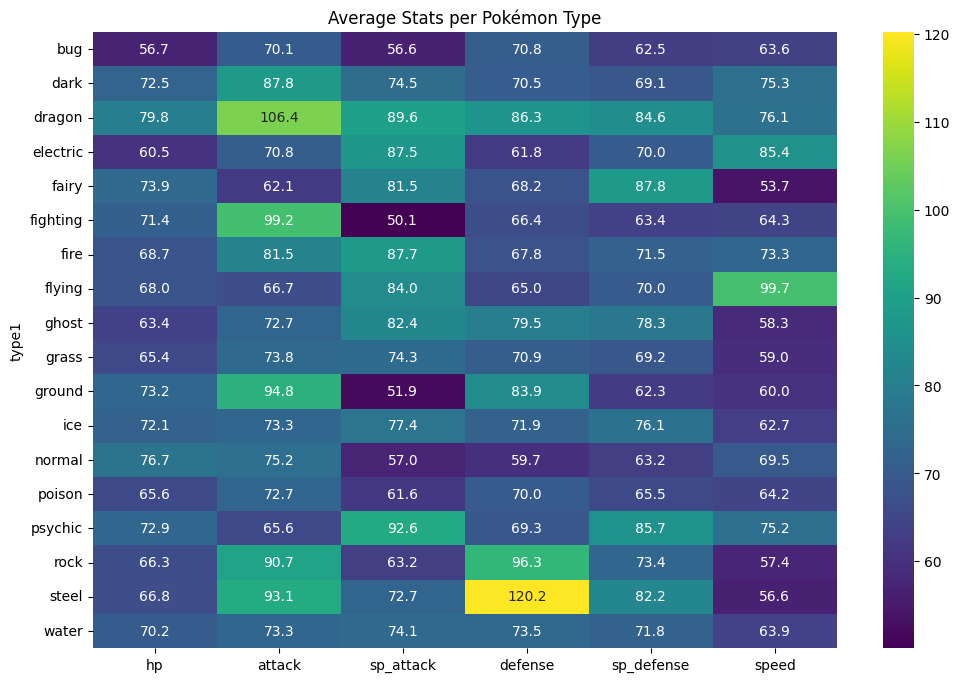

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(
    avg_stats,
    cmap = "viridis",
    annot = True,
    fmt = ".1f", # Force 1 decimal place (normal notation)
    # Dragon, Steel, and Flying types have high averages in Attack, Defense, and Speed
    # So they display scientific notation, but we don't want that
    cbar_kws={"format": "%.0f"}
)
plt.title("Average Stats per Pokémon Type")
plt.show()

Dragon types have high stats in most categories. For a while Dragon types were considered to be the best Pokemon, due to their high base stats across the board. On the other end of the spectrum, Bug types have low stats in most categories and are largely considered to be the worst. 

The Fairy type occupies 2 stats for the worst average, although if you ask any Pokemon player what the best type is, you'll hear a lot of 'Fairy' answers. The Fairy type does well in HP, sp. attack, and sp. defense and has good type match ups against some of the most powerful types, including Dragon. This finding suggests that raw stats are not everything, and that favorable type matchups against other great types can elevate a types position in the meta game.

We can also take a look at which types have higher base stat totals than others.

In [46]:
# Melt to long format so each type gets the Pokémon
pk_long_total = pk.melt(
    id_vars=['name', 'base_total'], 
    value_vars=['type1', 'type2'],
    value_name='type'
).dropna(subset=['type'])

# Group by type and calculate average base_total
avg_total = pk_long_total.groupby('type')['base_total'].mean()

# Find the type with the highest average
best_total_type = avg_total.idxmax()
best_total_value = avg_total.max()

# Find the type with the lowest average
worst_total_type = avg_total.idxmin()
worst_total_value = avg_total.min()

print(f"Type with highest average base_total: {best_total_type} ({best_total_value:.2f})")
print(f"Type with lowest average base_total: {worst_total_type} ({worst_total_value:.2f})\n")
print(avg_total.sort_values(ascending=False))

Type with highest average base_total: dragon (513.00)
Type with lowest average base_total: bug (380.44)

type
dragon      513.000000
steel       493.673913
psychic     463.792683
fighting    456.584906
fire        453.584615
dark        447.740000
ice         447.131579
rock        446.983051
ghost       444.804878
flying      441.734694
electric    440.145833
ground      428.121212
fairy       425.808511
water       424.038168
grass       413.408163
normal      401.669725
poison      397.909091
bug         380.441558
Name: base_total, dtype: float64


Dragon, Steel, and Psychic types make up the top 3 in highest average base stat total. Normal, poison, and bug make up the bottom 3. We saw in our heatmap that Dragon types performed well in most stats, and many of what are considered to be the strongest pokemon (pseudo-legendaries or legendaries) are Dragon types. Steel and Psychic have high stat values that are consolidated in one or two stats, such as Steel types having really high HP and Defense but very low sp. defense. Dragon and Steel types are also rather uncommon, their rarity contributing to their strength from a design standpoint. 

Normal, posion, and bug types are the weakest in raw base stats. These Pokemon are exceedingly common and appear early in each generation. From a design perspective, the developers might intend for these to be 'beginner Pokemon' that are not too strong but players can still form a connection with. 

Now that we've determined how common each type is and what stat each type tends to be good or bad in, let's lastly look at something less combat related and more of a fun-fact: are certain Pokemon types happier than others? 

Happiness has very little to do with combat, with the exception of happiness-based moves like Return and Frustration and some mechanics from later generations. We've been deep into stats and meta gaming, let's get a little less serious.

We'll need to examine the Pokemon for each stat along with their respective Happiness value. We'll then look at which type has the highest and lowest average base happiness value. Happiness is a stat that can grow through player intervention, and the stat cap for every Pokemon is the same at 255. 

In [43]:
# Combine type1 and type2 into a long-format DataFrame
pk_long = pk.melt(
    id_vars=['name', 'base_happiness'], 
    value_vars=['type1', 'type2'],
    value_name='type'
).dropna(subset=['type'])

# Group by type and calculate average base_happiness
avg_happiness = pk_long.groupby('type')['base_happiness'].mean()

# Find the type with the highest average
best_happiness_type = avg_happiness.idxmax()
best_happiness_value = avg_happiness.max()

# Find the type with the lowest average
worst_happiness_type = avg_happiness.idxmin()
worst_happiness_value = avg_happiness.min()

print(f"Type with highest average base_happiness: {best_happiness_type} ({best_happiness_value:.2f})")
print(f"Type with lowest average base_happiness: {worst_happiness_type} ({worst_happiness_value:.2f})\n")
print(avg_happiness.sort_values(ascending=False))

Type with highest average base_happiness: normal (69.59)
Type with lowest average base_happiness: dragon (44.66)

type
normal      69.587156
poison      69.393939
fairy       69.255319
grass       68.775510
water       68.091603
electric    67.291667
bug         67.272727
ground      67.121212
fire        67.076923
psychic     65.792683
rock        64.067797
fighting    63.962264
ice         63.552632
flying      63.469388
ghost       60.487805
steel       54.565217
dark        51.100000
dragon      44.659091
Name: base_happiness, dtype: float64


The top 3 happiest types are Normal, Poison, and Fairy. Normal and Fairy make a lot of sense, as these are supposed to represent standard pet-like animals (normal types) and more whimsical and happy creatures (fairy types). Poison being this high is surprising, as it doesn't intuitively make a lot of sense for aggressive insects and piles of garbage to be happy. 

Steel, dark, and dragon types are the least happy. Interestingly enough, this top and bottom 3 looks very similar to the one found when analyzing base stat totals! One could assume that Dark Pokemon tend to be more evil, Dragon types might have a hard time opening up because of how rare they are, and Steel types are steely. 

We can also look into how many friendship evolutions are of a certain type. 

In [50]:
import requests
from bs4 import BeautifulSoup

# URL of the friendship evolution page
url = "https://pokemondb.net/evolution/friendship"

# Request the page
resp = requests.get(url)
resp.raise_for_status()

soup = BeautifulSoup(resp.text, "html.parser")

# Find all Pokémon names (they are in <a class="ent-name">)
pokemon_names = [a.get_text(strip=True) for a in soup.find_all("a", class_="ent-name")]

In [52]:
# Print list as a dataframe for readability
df_friendship = pd.DataFrame({
    "pokemon": pokemon_names
})
print(df_friendship)

       pokemon
0        Pichu
1      Pikachu
2       Cleffa
3     Clefairy
4    Igglybuff
5   Jigglypuff
6       Golbat
7       Crobat
8       Meowth
9      Persian
10     Chansey
11     Blissey
12       Eevee
13      Espeon
14       Eevee
15     Umbreon
16       Eevee
17     Sylveon
18    Munchlax
19     Snorlax
20      Togepi
21     Togetic
22     Azurill
23      Marill
24       Budew
25     Roselia
26   Chingling
27    Chimecho
28     Buneary
29     Lopunny
30       Riolu
31     Lucario
32      Woobat
33     Swoobat
34    Swadloon
35    Leavanny
36  Type: Null
37    Silvally
38        Snom
39    Frosmoth


From this list, most of the happiness evolutions are Normal or Fairy type Pokemon. There is no Dragon happiness evolution, but there are Steel (Riolu -> Lucario) and Dark (Eevee -> Umbreon) types. 

It's hard to gauge exactly why certain types or Pokemon have higher base happiness values than others without doing a full analysis of their Pokedex entries or reading into the lore. What we can see from this data set is that Normal and Fairy types are happier and many evolve because of that while Dragons, Steel and Dark types are cagey and take some time to open up to their trainers. 